In [3]:
!pip install brian2

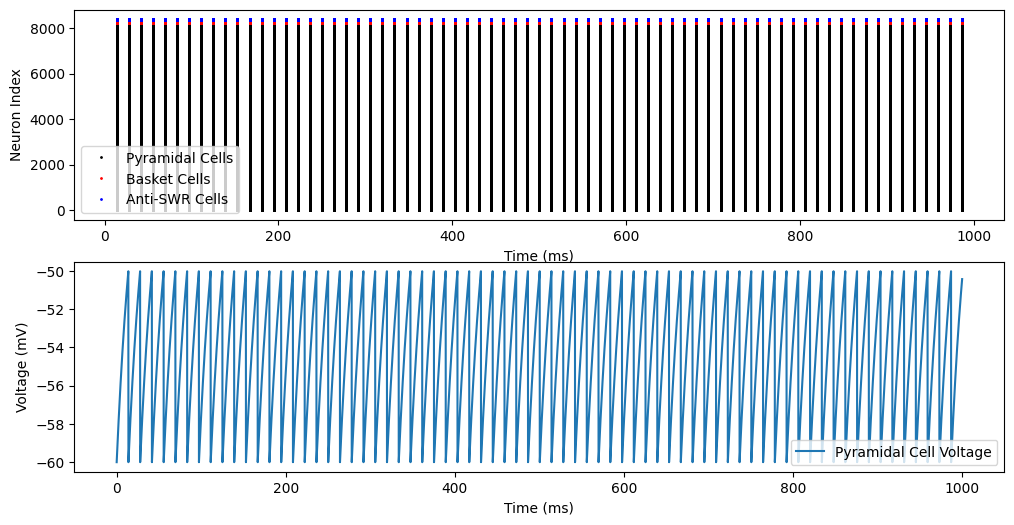

In [12]:
start_scope()

from brian2 import *


# Parameters
N_P = 8200  # Number of pyramidal cells
N_B = 135   # Number of PV-basket cells
N_A = 50    # Number of anti-SWR cells
tau = 20*ms  # Membrane time constant
V_rest = -60*mV
V_reset = -60*mV
V_thr = -50*mV
E_exc = 0*mV
E_inh = -70*mV

# Synaptic time constants
tau_exc = 2*ms
tau_inh_B = 1.5*ms
tau_inh_A = 4*ms

# Synaptic strengths (example values, adjust based on paper)
g_PB = 0.7*nS
g_BP = 0.05*nS
g_BA = 8*nS
g_AP = 6*nS
g_AA = 4*nS

# External input
I_ext = 200*pA  # Background current

# Neuron equations
eqs = '''
dV/dt = (V_rest - V)/tau + I_ext/C : volt
dg_exc/dt = -g_exc/tau_exc : siemens
dg_inh/dt = -g_inh/tau_inh_B : siemens
C : farad (constant)
'''


# Define neuron groups
P = NeuronGroup(N_P, eqs, threshold='V > V_thr', reset='V = V_reset', method='euler')
B = NeuronGroup(N_B, eqs, threshold='V > V_thr', reset='V = V_reset', method='euler')
A = NeuronGroup(N_A, eqs, threshold='V > V_thr', reset='V = V_reset', method='euler')

# Initial values
P.V = V_rest
B.V = V_rest
A.V = V_rest
P.C = 200*pF # Ensure C has units of farad
B.C = 200*pF
A.C = 200*pF


# Synapses

S_PB = Synapses(P, B, 'w : siemens', on_pre='g_exc_post += w')
S_PB.connect(p=0.5)  # 50% connection probability
S_PB.w = g_PB

S_BP = Synapses(B, P, 'w : siemens', on_pre='g_inh_post += w')
S_BP.connect(p=0.2)
S_BP.w = g_BP

S_BA = Synapses(B, A, 'w : siemens', on_pre='g_inh_post += w')
S_BA.connect(p=0.6)
S_BA.w = g_BA

S_AP = Synapses(A, P, 'w : siemens', on_pre='g_inh_post += w')
S_AP.connect(p=0.01)
S_AP.w = g_AP

S_AA = Synapses(A, A, 'w : siemens', on_pre='g_inh_post += w')
S_AA.connect(p=0.6)
S_AA.w = g_AA



# Monitors
spike_mon_P = SpikeMonitor(P)
spike_mon_B = SpikeMonitor(B)
spike_mon_A = SpikeMonitor(A)
state_mon_P = StateMonitor(P, 'V', record=[0, 1, 2])

# Run the simulation
run(1*second)

# Plot results
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(211)
plt.plot(spike_mon_P.t/ms, spike_mon_P.i, '.k', markersize=2, label="Pyramidal Cells")
plt.plot(spike_mon_B.t/ms, spike_mon_B.i+N_P, '.r', markersize=2, label="Basket Cells")
plt.plot(spike_mon_A.t/ms, spike_mon_A.i+N_P+N_B, '.b', markersize=2, label="Anti-SWR Cells")
plt.xlabel('Time (ms)')
plt.ylabel('Neuron Index')
plt.legend()

plt.subplot(212)
plt.plot(state_mon_P.t/ms, state_mon_P.V[0]/mV, label="Pyramidal Cell Voltage")
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (mV)')
plt.legend()
plt.show()
